# Homework — Customer Segmentation with Wholesale Customers

## Brief

Bạn là analyst cho một nhà phân phối thực phẩm. Hãy dùng dữ liệu **Wholesale Customers** để trả lời một câu hỏi thực tế:

> Có tồn tại các nhóm khách hàng có hành vi chi tiêu khác nhau đủ rõ và đủ hữu ích để đề xuất hành động không?

Dữ liệu có 440 khách hàng và 6 nhóm chi tiêu hằng năm: `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`.

Đây là **notebook làm việc của bạn**, không phải chuỗi bước cần làm lại. Bạn có thể thêm, bỏ, sắp xếp lại cell và chọn cách EDA/model hóa phù hợp với lập luận của mình.

## Yêu cầu đầu ra

Nộp một báo cáo notebook có thể giúp người khác ra quyết định. Bài làm cần có:

- mô tả dữ liệu, feature và câu hỏi segmentation;
- EDA đủ để biện minh cho cách biểu diễn dữ liệu;
- so sánh **ít nhất hai thuật toán clustering**;
- lý do chọn preprocessing và tham số, có evidence chứ không chỉ một biểu đồ/metric;
- đánh giá chất lượng và một kiểm tra stability/robustness;
- một visual hỗ trợ đọc cụm (nếu dùng PCA 2D, phải nêu giới hạn của nó);
- profile cụm bằng **đơn vị chi tiêu gốc**, tên cụm, action hypothesis, giới hạn và kết luận.

Không có yêu cầu về số lượng biểu đồ, thứ tự section hay thư viện. Chất lượng lập luận quan trọng hơn số cell/code.

## Quy ước và lưu ý

- Sáu cột chi tiêu là input mặc định cho clustering.
- `Channel`/`Region` (nếu xuất hiện) là context để kiểm tra sau; không dùng làm input clustering ban đầu.
- Giữ một bản dữ liệu gốc để profile/diễn giải. Data đã scale chỉ nên phục vụ model.
- Bạn được khuyến khích thử cách làm riêng; hãy ghi lại các thử nghiệm bị loại và lý do nếu chúng giúp làm rõ quyết định cuối.

Nộp `.ipynb` đã chạy đầy đủ. Tên file: `HW_clustering_<student_id>.ipynb`.

In [55]:
# Nếu môi trường thiếu thư viện, bỏ comment và chạy một lần:
# %pip install numpy pandas matplotlib scikit-learn scipy ucimlrepo

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
RANDOM_STATE = 42


# Dữ liệu

Cell này chỉ nạp dữ liệu và tách phần chi tiêu. Từ đây, bạn tự xây dựng analysis workspace của mình.

In [56]:
SPENDING_FEATURES = [
    'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'
]

candidate_paths = [
    Path('data/wholesale_customers.csv'),
    Path('../data/wholesale_customers.csv'),
    Path('../../data/wholesale_customers.csv'),
]
data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is not None:
    df = pd.read_csv(data_path)
    source = str(data_path)
else:
    try:
        from ucimlrepo import fetch_ucirepo
        dataset = fetch_ucirepo(id=292)
        df = dataset.data.features.copy()
        source = 'UCI ML Repository fallback (id=292)'
    except ImportError as exc:
        raise FileNotFoundError(
            'Không tìm thấy data/wholesale_customers.csv. '
            'Hãy đặt file đúng đường dẫn hoặc cài ucimlrepo để dùng fallback.'
        ) from exc

missing = sorted(set(SPENDING_FEATURES) - set(df.columns))
if missing:
    raise ValueError(f'File thiếu cột chi tiêu: {missing}')

X_raw = df[SPENDING_FEATURES].copy()
print(f'Nguồn: {source}')
print(f'Dữ liệu đầy đủ: {df.shape[0]} dòng × {df.shape[1]} cột')
print(f'Matrix chi tiêu: {X_raw.shape[0]} dòng × {X_raw.shape[1]} features')
display(df.head())


Nguồn: UCI ML Repository fallback (id=292)
Dữ liệu đầy đủ: 440 dòng × 7 cột
Matrix chi tiêu: 440 dòng × 6 features


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,12669,9656,7561,214,2674,1338
1,2,7057,9810,9568,1762,3293,1776
2,2,6353,8808,7684,2405,3516,7844
3,1,13265,1196,4221,6404,507,1788
4,2,22615,5410,7198,3915,1777,5185


# TODO A — Framing và audit dữ liệu

Hãy thêm cell/cell Markdown của bạn để trả lời:

- Một dòng dữ liệu đại diện cho điều gì? Những feature nào có ý nghĩa cho bài toán segmentation?
- Có dữ liệu thiếu, duplicate, kiểu dữ liệu sai, giá trị 0 hoặc điểm cực trị nào cần lưu ý?
- `Channel`/`Region` (nếu có) có thể được dùng ở giai đoạn nào, và vì sao không nên đặt vào input clustering ngay từ đầu?
- Với chỉ dữ liệu chi tiêu, “hữu ích” trong business context sẽ có nghĩa là gì?

Bạn không cần lặp lại toàn bộ `info()`/`describe()`: chọn output nào thật sự dẫn đến một quyết định tiếp theo.

In [57]:
# Analysis workspace — thêm cell EDA của bạn bên dưới hoặc thay cell này.
# Gợi ý khởi đầu (không bắt buộc):
df.info()

print("\nDữ liệu bị thiếu:")
print(df.isnull().sum())

print("\nDữ liệu bị trùng lặp:", df.duplicated().sum())

print("\nThống kê chung:")
display(X_raw.describe().T)


<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Fresh             440 non-null    int64
 2   Milk              440 non-null    int64
 3   Grocery           440 non-null    int64
 4   Frozen            440 non-null    int64
 5   Detergents_Paper  440 non-null    int64
 6   Delicassen        440 non-null    int64
dtypes: int64(7)
memory usage: 24.2 KB

Dữ liệu bị thiếu:
Channel             0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

Dữ liệu bị trùng lặp: 0

Thống kê chung:


,count,mean,std,min,25%,50%,75%,max
Fresh,440.00,"12,000.30","12,647.33",3.00,"3,127.75","8,504.00","16,933.75","112,151.00"
Milk,440.00,"5,796.27","7,380.38",55.00,"1,533.00","3,627.00","7,190.25","73,498.00"
Grocery,440.00,"7,951.28","9,503.16",3.00,"2,153.00","4,755.50","10,655.75","92,780.00"
Frozen,440.00,"3,071.93","4,854.67",25.00,742.25,"1,526.00","3,554.25","60,869.00"
Detergents_Paper,440.00,"2,881.49","4,767.85",3.00,256.75,816.50,"3,922.00","40,827.00"
Delicassen,440.00,"1,524.87","2,820.11",3.00,408.25,965.50,"1,820.25","47,943.00"


**Nhận xét:**
* Mỗi dòng đại diện cho một khách hàng và chi tiêu của họ cho từng mặt hàng mỗi năm. Các biến `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen` là các biến mang ý nghĩa cho bài toán segmentation.
* Dữ liệu không bị trùng lặp hay bị mất. Giá trị trung vị nhỏ hơn rất nhiều so với giá trị tối đa có thể cho thấy có outliers và có khả năng phân phối lệch phải.
* `Channel` và `Region` là các biến phân loại không nên được dùng chung với các biến số khác trong bài toán phân cụm. Tuy nhiên chúng vẫn có giá trị tham khảo đối chiếu với kết quả cuối cùng.
* Sự hữu ích trong bối cảnh kinh tế là khi bài toán có thể phân cụm được các mặt hàng thường được yêu thích hay mua chung với nhau tùy theo từng tệp khách hàng. Từ đó các đơn vị bán lẻ có thể sắp sếp mặt hàng để phù hợp với tiêu chí lựa chọn của người mua.

# TODO B — EDA tự do, nhưng có chủ đích

Tự chọn visual và phép tóm tắt phù hợp. EDA của bạn cần làm rõ các câu hỏi sau:

- Phân phối/độ lệch/outlier nào sẽ ảnh hưởng cách tính khoảng cách?
- Feature nào có thang đo hoặc mức biến thiên khác đáng kể?
- Có quan hệ giữa các nhóm chi tiêu nào đáng để chú ý khi đọc cluster profile?
- Những quan sát này dẫn bạn đến thử preprocessing hoặc model nào?

Gắn một đoạn nhận xét ngắn dưới mỗi visual quan trọng. Không cần vẽ mọi loại biểu đồ nếu chúng không giúp trả lời câu hỏi.

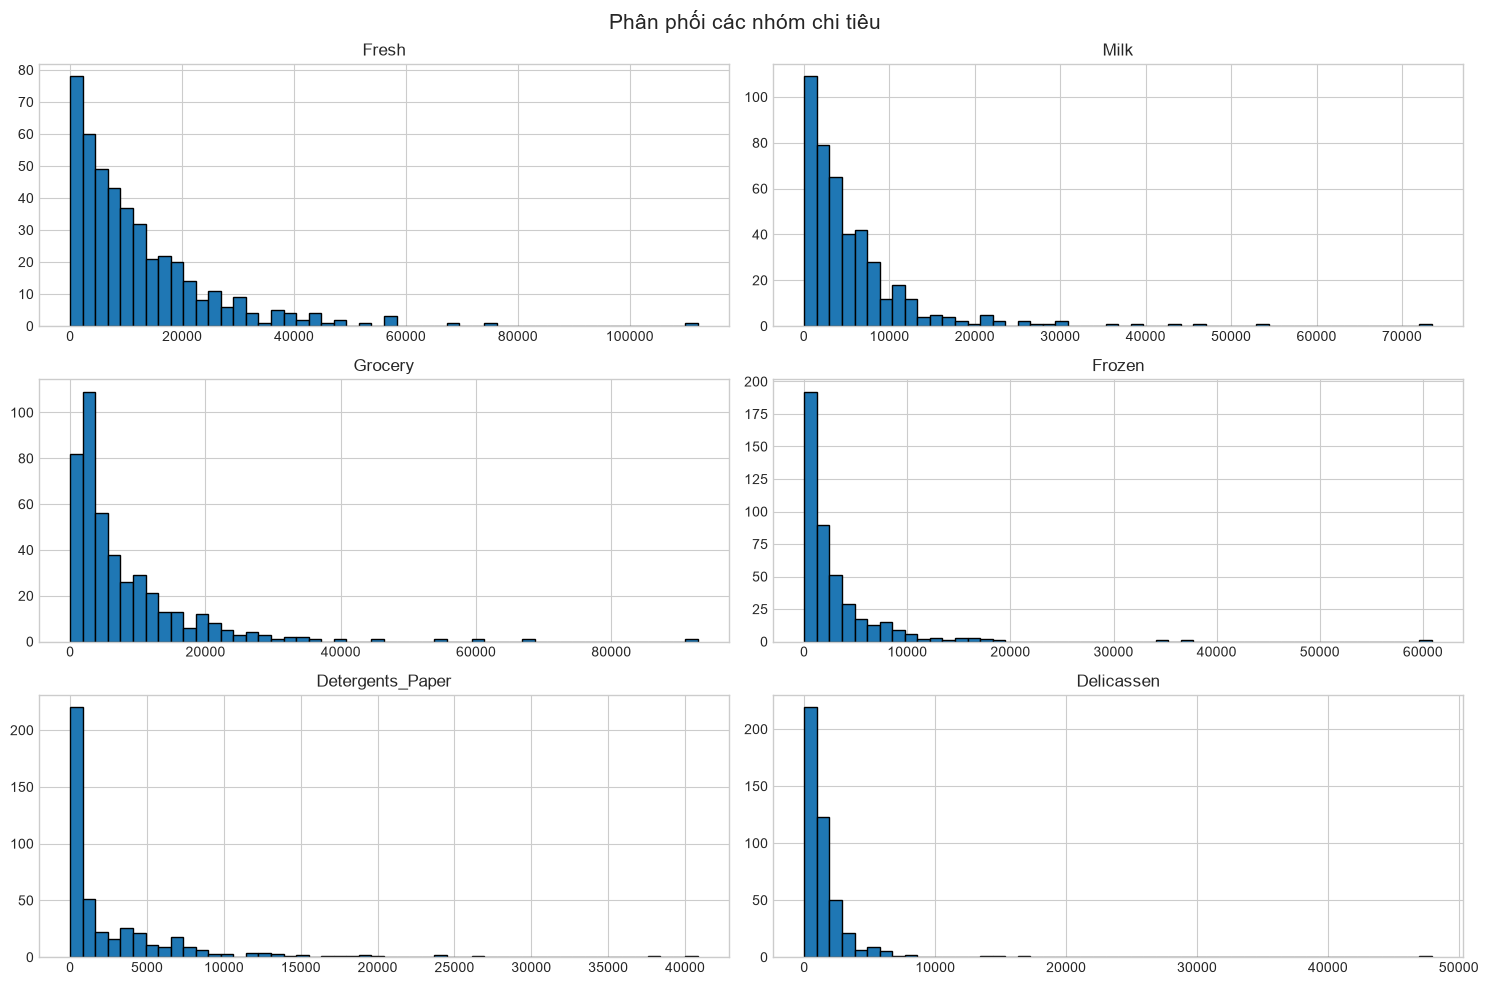

In [58]:
import seaborn as sns

X_raw.hist(bins=50, figsize=(15, 10), edgecolor='black')
plt.suptitle("Phân phối các nhóm chi tiêu", fontsize=15)
plt.tight_layout()
plt.show()


Kiểm tra phân phối các nhóm chi tiêu cho thấy xu hướng chung đều lệch phải khá nặng.

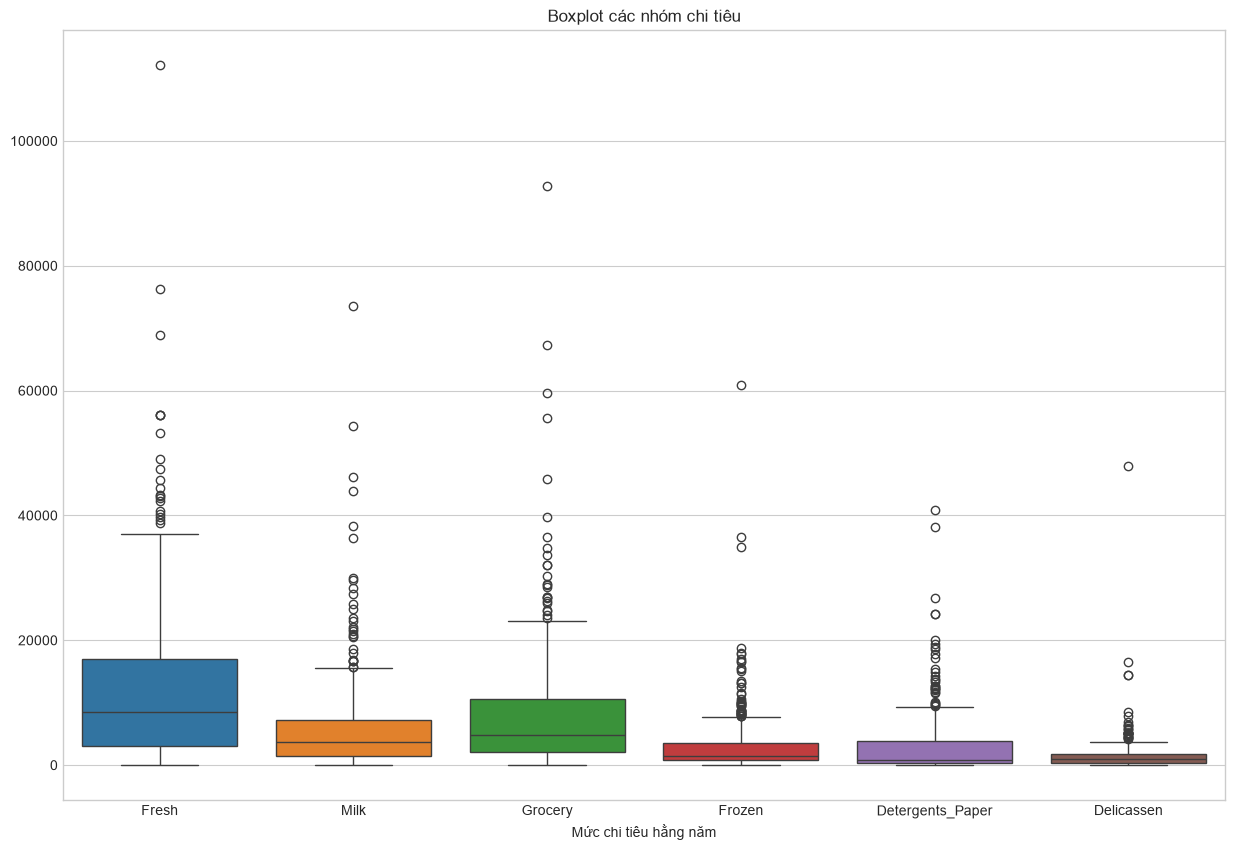

In [59]:
plt.figure(figsize=(15, 10))
sns.boxplot(data=X_raw)
plt.title("Boxplot các nhóm chi tiêu")
plt.xlabel("Mức chi tiêu hằng năm")
plt.show()

Số lượng outlier ở mỗi nhóm chi tiêu là rất nhiều và trải rộng và cao hơn rất nhiều so với trung vị. Cho thấy xu hướng mua hàng chỉ có đặc biệt đắt giá chứ ít có mặt hàng đặc biệt rẻ.

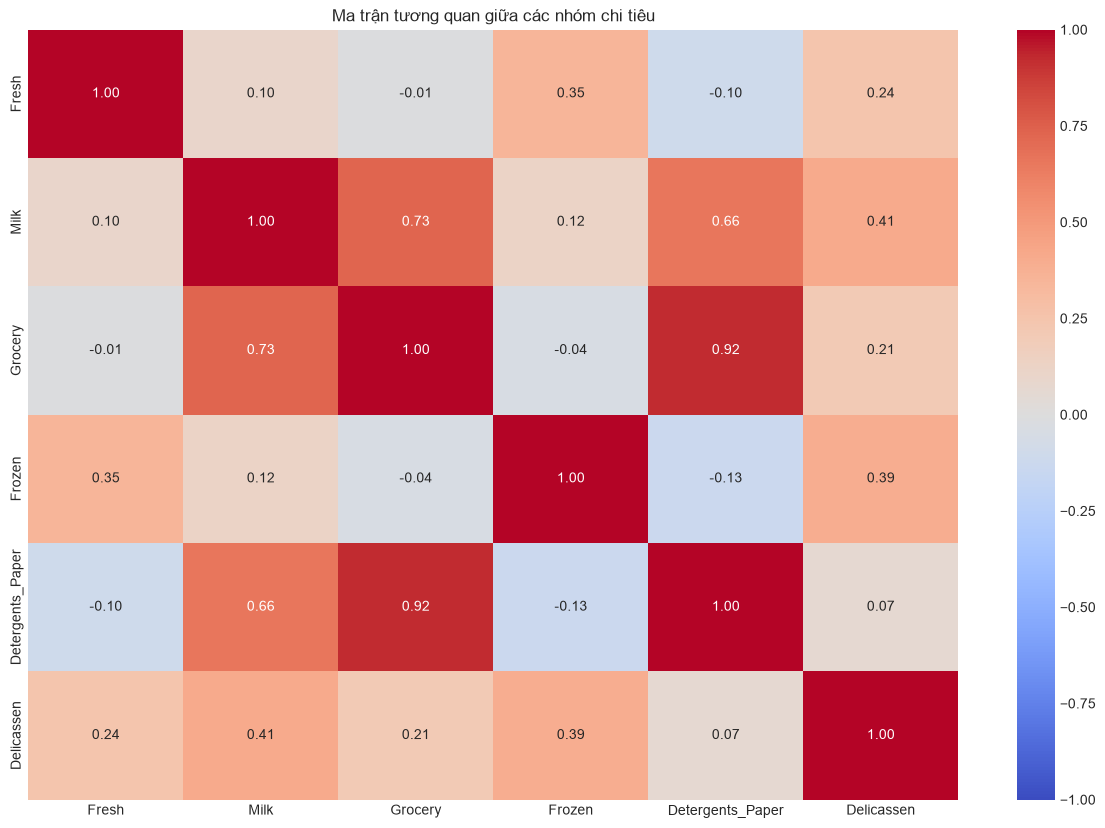

In [60]:
plt.figure(figsize=(15, 10))
corr_matrix = X_raw.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Ma trận tương quan giữa các nhóm chi tiêu")
plt.show()

**Nhận xét:**
* Nhiều outliers sẽ ảnh hưởng đến quá trình tính toán khoảng cách của K-means khiến mô hình không học được cụm hành vi chung của nhóm đông.
* `Delicassen` và `Detergents_Paper` có scale và phương sai tương đối nhỏ hơn so với các biến còn lại khiến các biến này bị áp đảo bởi các giá trị lớn hơn, không gây được ảnh hưởng đến quy tắc chung.
* Các biến `Grocery` và `Detergents_Paper` cũng như `Milk` có tương quan thuận với nhau rất đáng để quan sát khi tạo thành cụm.
* Sử dụng phép biến đổi logarith để phân phối chuẩn hơn, giảm bớt giá trị của outlier. Sau đó dùng scaler để đưa các biến về cùng thang đo thuận tiện cho việc tính toán khoảng cách.

# TODO C — Chọn representation và preprocessing

Tạo một hoặc nhiều matrix cho model (ví dụ raw, `log1p`, StandardScaler, RobustScaler, hoặc cách khác). Bạn tự quyết định cách so sánh, nhưng cần:

- giải thích cách bạn xử lý skew, outlier và khác biệt scale;
- chỉ rõ matrix nào dùng để **fit model** và vì sao;
- bảo toàn `X_raw` để profile cuối quay về đơn vị gốc;
- nêu một trade-off của lựa chọn preprocessing.

> Có thể dùng `np.log1p(X_raw)` nếu phù hợp với dữ liệu không âm. Đây là gợi ý công cụ, không phải yêu cầu.

In [61]:
# Analysis workspace — tạo X_model hoặc các candidate matrix của bạn tại đây.
# Ví dụ tối thiểu (chỉ chạy nếu bạn chủ động bỏ comment):
# Candidate 1: StandardScaler, không xử lí skew
X_raw_std = StandardScaler().fit_transform(X_raw)

# Candidate 2: raw + RobustScaler (chỉ xử lý scale bằng trung vị, bỏ qua skew)
X_raw_robust = RobustScaler().fit_transform(X_raw)

# Candidate 3: log1p + StandardScaler (xử lý skew, scale)
X_log = np.log1p(X_raw)
X_log_std = StandardScaler().fit_transform(X_log)

# Candidate 4: log1p + RobustScaler (xử lý skew, scale bền hơn với outlier)
X_log_robust = RobustScaler().fit_transform(X_log)



candidates = {
    'raw + StandardScaler': X_raw_std,
    'raw + RobustScaler': X_raw_robust,
    'log1p + StandardScaler': X_log_std,
    'log1p + RobustScaler': X_log_robust
}

print('So sánh silhouette và Davies-Bouldin của KMeans (k=4) trên từng candidate:')
for name, Xc in candidates.items():
    km = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE).fit(Xc)
    sil = silhouette_score(Xc, km.labels_)
    db = davies_bouldin_score(Xc, km.labels_)
    sizes = np.bincount(km.labels_)
    print(f'{name:25s} | Silhouette: {sil:.3f} | Davies-Bouldin: {db:.3f} | Phân bổ cụm: {sizes}')


So sánh silhouette và Davies-Bouldin của KMeans (k=4) trên từng candidate:
raw + StandardScaler      | Silhouette: 0.348 | Davies-Bouldin: 1.147 | Phân bổ cụm: [110 315  10   5]
raw + RobustScaler        | Silhouette: 0.515 | Davies-Bouldin: 0.867 | Phân bổ cụm: [ 31  41 367   1]
log1p + StandardScaler    | Silhouette: 0.188 | Davies-Bouldin: 1.541 | Phân bổ cụm: [ 61 129 132 118]
log1p + RobustScaler      | Silhouette: 0.197 | Davies-Bouldin: 1.411 | Phân bổ cụm: [122 158  96  64]


In [62]:
# Quyết định chọn Candidate 2 làm representation chính thức để huấn luyện mô hình
X_model = X_log_std

**Nhận xét:**
* Với trường hợp dữ liệu raw chỉ được xử lý bằng StandardScaler hoặc RobustScaler ta thấy rằng chỉ số Silhouette và Davies-Bouldin rất tốt, tuy nhiên nếu nhìn vào số lượng điểm trong từng cụm ta thấy rõ sự mất cân bằng (một cụm chỉ có 1 điểm hoặc 5 điểm). Điều này được lý giải bởi sự ảnh hưởng của các outlier chưa được xử lý nằm cách xa tưởng chừng như được phân tách lý tưởng nhưng chỉ là nhiễu.
* Khi chuẩn hóa dữ liệu bằng log1p, các điểm outlier biến thiên nhẹ lại, giúp kéo gần các outlier và phân phối hẹp hơn. Lúc này chỉ số Silhouette và Davies-bouldin giữa hai phương pháp còn lại tương đương nhau, tuy log1p+StandardScaler có kết quả tốt hơn nhưng thực tế log1p+StandardScaler cho thấy độ phân cụm đồng đều hơn. Do đó có thể chọn log1p+StandardScaler để fit model.
* Trade off được nhìn thấy rõ ràng nhất là sự giảm tính tốt các chỉ số đo lường khi sử dụng log1p (ví dụ Silhouette giảm mạnh từ 0.515 về còn 0.197) lý giải bởi việc các outlier bị kéo gần về các điểm trung vị, tuy nhiên cũng vì vậy mô hình ít nhiễu hơn và cụm có thể được phân chia rõ ràng hơn.

# TODO D — Khám phá model

So sánh ít nhất **hai thuật toán**. Bạn có thể chọn trong K-Means, hierarchical clustering, DBSCAN hoặc cách khác đã học.

Với từng candidate đáng cân nhắc, ghi lại:

- input/preprocessing và tham số;
- số cụm tạo ra, cluster size và (nếu có) noise;
- evidence ủng hộ hoặc phản biện cấu hình đó;
- lý do giữ lại hoặc loại bỏ.

Bạn không phải thử mọi thuật toán hay mọi tham số. Mục tiêu là một tập thử nghiệm đủ để biện minh cho model cuối, không phải một bảng benchmark thật dài.

Đánh giá mô hình


,Algorithm,k,Inertia,Silhouette,Davies-Bouldin,Min_Size
0,K-Means,2,"1,844.06",0.29,1.35,188
1,Agglomerative,2,NaN,0.26,1.60,178
2,K-Means,3,"1,553.42",0.26,1.34,80
3,Agglomerative,3,NaN,0.25,1.54,53
4,K-Means,4,"1,386.86",0.19,1.54,61
5,Agglomerative,4,NaN,0.20,1.52,53
6,K-Means,5,"1,266.15",0.19,1.48,54
7,Agglomerative,5,NaN,0.20,1.39,18
8,K-Means,6,"1,174.76",0.20,1.43,20
9,Agglomerative,6,NaN,0.17,1.49,18


Độ tương đồng giữa 2 thuật toán


k,ARI (KMeans vs Agglomerative)
2,0.638946
3,0.449070
4,0.397667
5,0.368026


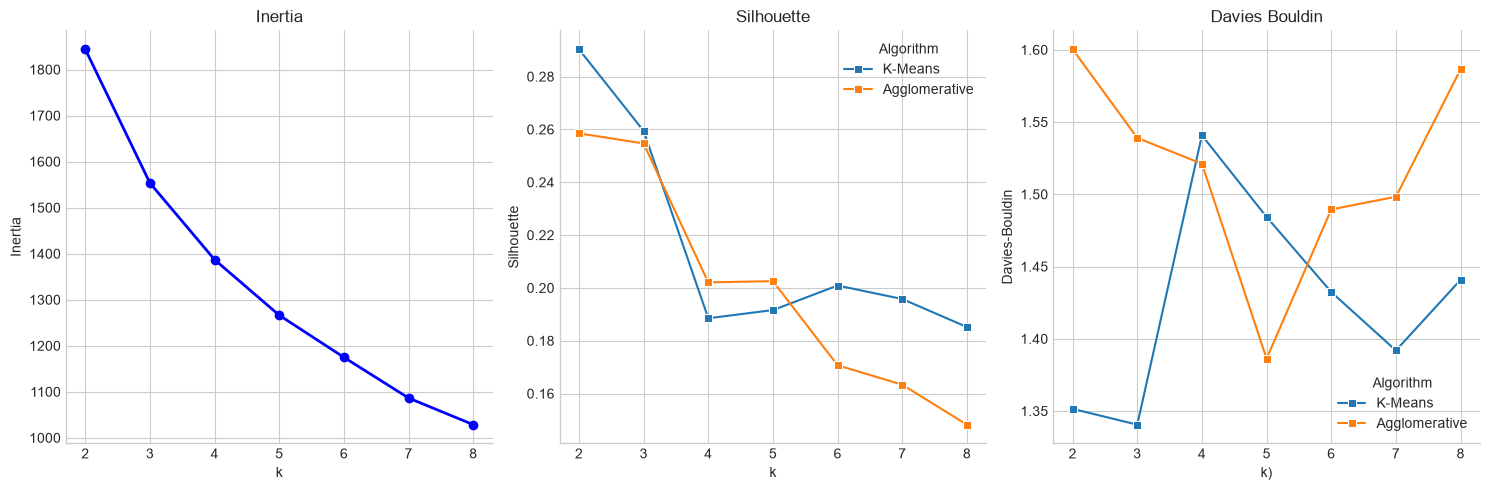

In [63]:
# Analysis workspace — fit các model bạn muốn so sánh tại đây.
# Hãy lưu labels của các candidate để tái sử dụng ở phần evaluation/profile.
# Ví dụ khung (không bắt buộc):
# model = KMeans(n_clusters=..., n_init=..., random_state=RANDOM_STATE)
# labels = model.fit_predict(X_model)

results = []
ari_scores = []

for k in range(2, 9):
    #Kmean
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_model)
    labels_km = km.labels_

    #Agglomerative
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward').fit(X_model)
    labels_agg = agg.labels_
    
    results.append({
        'Algorithm': 'K-Means', 
        'k': k,
        'Inertia': km.inertia_,
        'Silhouette': silhouette_score(X_model, labels_km),
        'Davies-Bouldin': davies_bouldin_score(X_model, labels_km),
        'Min_Size': np.bincount(labels_km).min()
    })
    
    results.append({
        'Algorithm': 'Agglomerative', 
        'k': k,
        'Inertia': np.nan, 
        'Silhouette': silhouette_score(X_model, labels_agg),
        'Davies-Bouldin': davies_bouldin_score(X_model, labels_agg),
        'Min_Size': np.bincount(labels_agg).min()
    })
    
    # Calculate ARI
    if k in [2, 3, 4, 5]:
        ari = adjusted_rand_score(labels_km, labels_agg)
        ari_scores.append({'k': k, 'ARI (KMeans vs Agglomerative)': ari})


res_df = pd.DataFrame(results)
ari_df = pd.DataFrame(ari_scores)

# 2. HIỂN THỊ BẢNG KẾT QUẢ ĐÃ ĐƯỢC FORMAT CHUYÊN NGHIỆP
print("Đánh giá mô hình")
display(res_df)

print("Độ tương đồng giữa 2 thuật toán")
display(ari_df.style.set_properties(**{'text-align': 'center'}).hide(axis='index'))


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Inertia
km_res = res_df[res_df['Algorithm'] == 'K-Means']
axes[0].plot(km_res['k'], km_res['Inertia'], marker='o', color='blue', linewidth=2)
axes[0].set_title('Inertia', fontsize=12)
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

# Silhouette
sns.lineplot(data=res_df, x='k', y='Silhouette', hue='Algorithm', marker='s', ax=axes[1])
axes[1].set_title('Silhouette', fontsize=12)
axes[1].set_xlabel('k')

# Davies BOuldin
sns.lineplot(data=res_df, x='k', y='Davies-Bouldin', hue='Algorithm', marker='s', ax=axes[2])
axes[2].set_title('Davies Bouldin', fontsize=12)
axes[2].set_xlabel('k)')

sns.despine()
fig.tight_layout()
plt.show()


**Nhận xét:**
* Điểm cùi chỏ được tạo ra không quá rõ ràng.
* Chỉ số Silhouette ở cả 2 thuật toán K-means và Agglomerative đều cao nhất khi k = 2 và giảm dần khi k tăng. 
* Chỉ số Davies Bouldin ở K-means cho thấy chỉ số chỉ tốt ở khoảng k = 2 và k = 3, chỉ số tăng mạnh khi k tăng lên 4. Trong khi đó ở Agglomerative, chỉ số Davies Bouldin lại ngược với K-means.
* Chỉ số ARI đo mức độ tương đồng giữa 2 thuật toán, cho thấy ở k = 2, hai thuật toán tương đồng nhau với chỉ số cao nhất và giảm dần khi k tăng. Khi k tăng, số lượng cụm tăng, chỉ số ARI thấp cho thấy hai thuật toán đang phân tách cụm khác nhau về bản chất và ý nghĩa. Do đó có thể chọn k = 2 là cấu hình an toàn nhất.

# TODO E — Evaluation, parameter choice và stability

Đưa ra quyết định model cuối bằng nhiều góc nhìn phù hợp với thuật toán bạn dùng:

- **Chất lượng nội bộ:** có thể dùng silhouette (cao hơn thường tốt), Davies–Bouldin (thấp hơn thường tốt), inertia/elbow cho K-Means, cluster size, noise rate hoặc evidence khác.
- **Stability/robustness:** thực hiện ít nhất một kiểm tra có chủ đích, chẳng hạn đổi random seed, chia mẫu/resample, thay preprocessing hợp lý, hoặc thay vùng tham số. Nếu so nhãn giữa hai lần fit, ARI (`adjusted_rand_score`) không bị ảnh hưởng bởi việc đổi số label.
- **Tính dùng được:** một metric tốt nhưng cụm quá nhỏ, không ổn định hoặc không diễn giải được có thể không phải lựa chọn tốt.

Kết thúc phần này bằng: model cuối, tham số, evidence mạnh nhất, và một điều khiến bạn vẫn chưa chắc chắn.

In [64]:
km_final = KMeans(n_clusters=2, n_init=20, random_state=RANDOM_STATE)
labels_final = km_final.fit_predict(X_model)

# Đánh giá chất lượng nội bộ
sil_final = silhouette_score(X_model, labels_final)
db_final = davies_bouldin_score(X_model, labels_final)
inertia_final = km_final.inertia_
cluster_sizes = pd.Series(labels_final).value_counts().sort_index()

print("Chât lượng nội bộ K-means (k = 2)\n")
print(f"Silhouette Score : {sil_final:.4f}")
print(f"Davies-Bouldin   : {db_final:.4f}")
print(f"Inertia          : {inertia_final:.2f}")
print(f"Kích thước cụm   :\n{cluster_sizes.to_string()}")

Chât lượng nội bộ K-means (k = 2)

Silhouette Score : 0.2903
Davies-Bouldin   : 1.3515
Inertia          : 1844.06
Kích thước cụm   :
0    252
1    188


In [65]:
def test_seed_stability(seeds_list, baseline_labels, X_matrix, k=2):
    stability_results = []
    for seed in seeds_list:
        km_test = KMeans(n_clusters=k, n_init=20, random_state=seed)
        test_labels = km_test.fit_predict(X_matrix)
        
        ari = adjusted_rand_score(baseline_labels, test_labels)
        
        stability_results.append({
            'Random seed': seed,
            'ARI score': ari
        })
        
        print(f"ARI (Baseline vs Seed {seed:<5}): {ari:.4f}")

test_seeds = [123, 999, 2026, 8888, 777, 1024]

test_seed_stability(
    seeds_list=test_seeds, 
    baseline_labels=labels_final, 
    X_matrix=X_model, 
    k=2
)



ARI (Baseline vs Seed 123  ): 1.0000
ARI (Baseline vs Seed 999  ): 1.0000
ARI (Baseline vs Seed 2026 ): 1.0000
ARI (Baseline vs Seed 8888 ): 1.0000
ARI (Baseline vs Seed 777  ): 1.0000
ARI (Baseline vs Seed 1024 ): 1.0000


**Nhận xét:**
* Với k = 2, ARI = 1 ở mọi seed cho thất mô hình ổn định, thuật toán K-means luôn trả về cùng một cách chia cụm.
* Lựa chọn mô hình: K-means với k = 2, dữ liệu qua biến đối log1p và StandardScaler vì với thông số này các đánh giá Silhouette và Davies Bouldin tốt nhất đồng thời kích thước các cụm cân đối và độ ổn định cao. Tuy nhiên với k = 2 vẫn có thể chưa mang nhiều ý nghĩa, có thể cân nhắc k = 3 với các thông số đánh giá thấp hơn nhưng vẫn ở trong mức tốt và đáng cân nhắc.

# TODO F — Visualize để giao tiếp, không để chứng minh quá mức

Tạo visual phù hợp cho model cuối. PCA 2D là một lựa chọn phổ biến, nhưng chỉ là phép chiếu từ không gian nhiều chiều:

- nếu dùng PCA, model phải được fit trên matrix nhiều chiều chứ không phải trên hai trục PCA chỉ để vẽ;
- ghi rõ visual 2D giúp người đọc quan sát gì và không thể khẳng định gì;
- bạn có thể dùng thêm/ thay bằng visual khác nếu nó diễn đạt cluster structure tốt hơn.


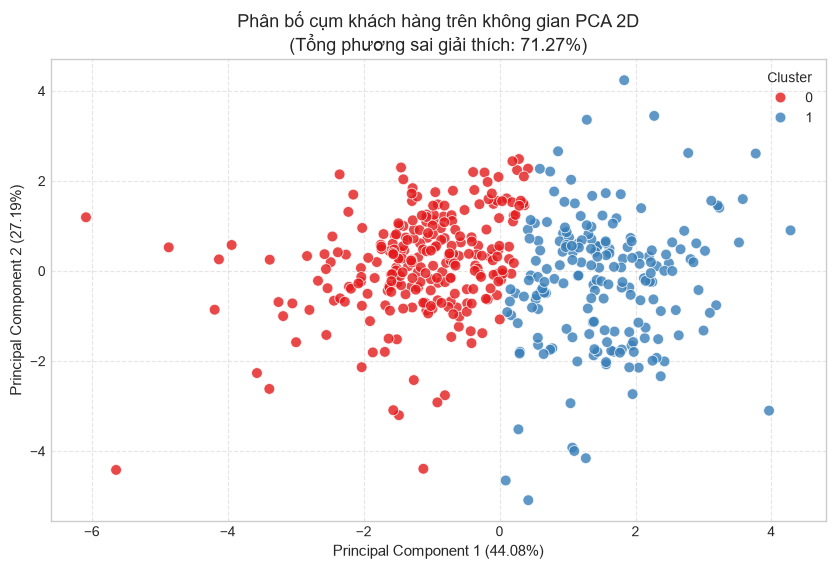

In [66]:
# Analysis workspace — visual cho model cuối.
# Có thể dùng PCA, nhưng không cần giới hạn ở PCA:
# coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_model)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_model)

# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca[:, 0], 
    y=X_pca[:, 1], 
    hue=labels_final, 
    palette='Set1', 
    alpha=0.8,
    s=60
)

explained_variance = pca.explained_variance_ratio_.sum()
plt.title(f"Phân bố cụm khách hàng trên không gian PCA 2D\n(Tổng phương sai giải thích: {explained_variance:.2%})", fontsize=13)
plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%})", fontsize=11)
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%})", fontsize=11)
plt.legend(title='Cluster', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


**Nhận xét:**
* Biểu đồ cho thấy hai cụm khách hàng được phân tách với kích thước và số lượng tương đối đồng đều và có phần giao thoa giữa hai cụm.
* Không thể khẳng định các điểm giao thoa là nằm chồng lên nhau vì đây chỉ là phép chiếu lên mặt phẳng 2D, trong thực tế dữ liệu có 6 chiều và các điểm này có thể nằm cách xa nhau.

# TODO G — Profile, đặt tên và action hypothesis

Quay về `X_raw`. Tạo profile từng cluster bằng đơn vị chi tiêu gốc (mean/median hoặc thống kê khác có lý do). Sau đó:

- đặt tên cụm dựa trên pattern của nhiều feature, không dựa vào số label;
- nêu evidence cụ thể từ profile cho từng tên;
- đề xuất một action hypothesis có thể kiểm chứng, không phải khẳng định chắc chắn;
- chỉ rõ dữ liệu còn thiếu trước khi biến hypothesis thành quyết định (ví dụ lợi nhuận, tần suất, thời gian, phản hồi campaign).

Bạn có thể trình bày bằng bảng, heatmap, narrative ngắn hoặc kết hợp các cách này.

Median chi tiêu theo cụm:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster,,,,,,
0,"10,347.50","1,871.00","2,406.00","2,225.00",327.50,749.50
1,"5,406.50","7,690.50","11,527.00","1,061.50","4,495.00","1,388.50"



Tỉ lệ median của cụm so với median toàn bộ:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster,,,,,,
0,1.22,0.52,0.51,1.46,0.40,0.78
1,0.64,2.12,2.42,0.70,5.51,1.44


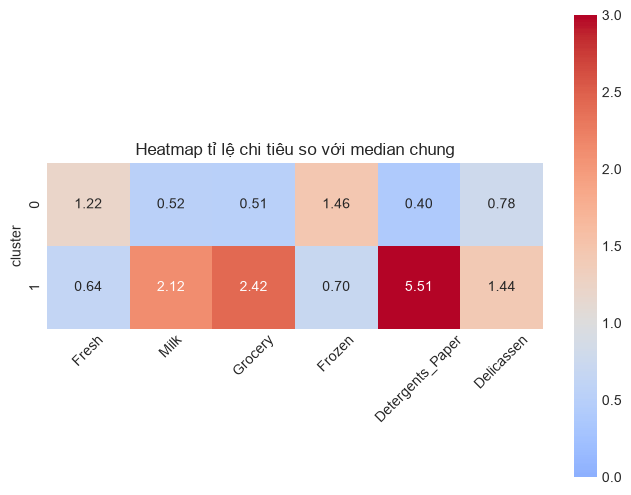

In [67]:
# Analysis workspace — profile trên X_raw và viết action hypothesis của bạn tại đây.
# Mẹo kỹ thuật (không bắt buộc):
# profile = X_raw.assign(cluster=labels_final).groupby('cluster').median()

profile = X_raw.assign(cluster=labels_final).groupby('cluster').median()
print("Median chi tiêu theo cụm:")
display(profile)

# Tính tỉ lệ median chi tiêu từng cụm so với median toàn bộ dữ liệu
overall_median = X_raw.median()
ratio_to_overall = profile.div(overall_median, axis=1)
print("\nTỉ lệ median của cụm so với median toàn bộ:")
display(ratio_to_overall)

# Vẽ heatmap tỉ lệ
plt.figure(figsize=(8, 6))
sns.heatmap(data=ratio_to_overall, annot=True, fmt=".2f", cmap="coolwarm", center=1, square=True, vmin=0, vmax=3)
plt.title("Heatmap tỉ lệ chi tiêu so với median chung")
plt.xticks(rotation=45)
plt.show()


In [68]:
print("Số lượng Horeca và Retail trong các cụm:")
cross_tab = pd.crosstab(labels_final, df['Channel'], rownames=['Cluster'], colnames=['Channel'], margins=True, margins_name='Total')
cross_tab = cross_tab.rename(columns={1: 'Horeca', 2: 'Retail'})
display(cross_tab)

Số lượng Horeca và Retail trong các cụm:


Channel,Horeca,Retail,Total
Cluster,,,
0,244,8,252
1,54,134,188
Total,298,142,440


### Đặt tên cụm
* Cụm 0: Khách hàng mua sỉ quy mô lớn ứng với kênh Horeca (nhà hàng khách sạn): Nhóm này có mức chi tiêu trung vị cho mặt hàng `Fresh` (thực phẩm tươi sống) và `Frozen` (đồ đông lạnh) cao hơn hẳn so với cụm còn lại, trong khi các mặt hàng tiêu dùng khô thấp hơn.
* Cụm 1: Khách hàng mua sỉ quy mô nhỏ và đồng đều ứng với kênh Retail (đại lý bán lẻ): Nhóm này thể hiện mức chi tiêu trung vị lớn vượt trội ở các mặt hàng `Grocery` (Hàng khô), `Milk` (Sữa) và `Detergents_Paper` (Giấy và chất tẩy rửa) đồng thời các mức chi tiêu trải rộng trên các mặt hàng.


### Action Hypothesis & Dữ liệu còn thiếu

* **Action Hypothesis:**
    * Cụm 0: Đẩy mạnh các gói dịch vụ giao hàng tươi sống định kỳ vào sáng sớm với chính sách ưu đãi vận chuyển riêng cho nguyên liệu tươi và đông lạnh.
    * Cụm 1: Áp dụng chiến lược bán chéo theo các combo sản phẩm tiêu dùng nhanh với chiết khấu theo sản lượng nhập hàng.

* **Dữ liệu còn thiếu trước khi đưa ra quyết định thương mại lớn:**
    * Biên lợi nhuận ở từng nhóm sản phẩm (chi tiêu cao không đồng nghĩa lợi nhuận cao).
    * Tần suất mua hàng thực tế và thời điểm gần đây nhất khách hàng đặt hàng.
    * Phản hồi hoặc lịch sử tham gia các chương trình khuyến mãi gần đây của khách hàng.

# TODO H — Executive summary

Viết 150–250 từ cho người ra quyết định:

1. Có nên dùng segmentation này ngay, thử nghiệm giới hạn, hay chưa nên dùng? Vì sao?
2. Quyết định model/preprocessing cuối và evidence ngắn gọn.
3. Hai insight profile quan trọng nhất.
4. Action thử trước và cách đánh giá nó.
5. Giới hạn quan trọng nhất của phân tích.

### Executive summary
* Nên triển khai segmentation này ở bản thử nghiệm trước, chưa nên đưa vào vận hành tuy mô hình đã phân loại được cụm khách hàng vì còn thiếu các kiểm chứng về lợi nhuận và tính hợp lý.
* Lựa chọn mô hình: K-means với k = 2, dữ liệu qua biến đối log1p và StandardScaler vì với thông số này các đánh giá Silhouette và Davies Bouldin tốt nhất đồng thời kích thước các cụm cân đối và độ ổn định cao. Tuy nhiên với k = 2 vẫn có thể chưa mang nhiều ý nghĩa, có thể cân nhắc k = 3 với các thông số đánh giá thấp hơn nhưng vẫn ở trong mức tốt và đáng cân nhắc.
* Hai insight quan trọng:
    1. Nhóm khách hàng horeca tập trung mua mạnh các mặt hàng tươi sống và đông lạnh, có thể để phục vụ mục đích kinh doanh dịch vụ ăn uống.
    2. Nhóm khách hàng retail mua nhiều các mặt hàng từ thực phẩm tới vệ sinh khăn giấy có thể cung cấp dịch vụ bán lẻ như các siêu thị mini hoặc tạp hóa.
* Triển khai mô hình bán chéo, combo sữa và đồ khô cho khoảng 100 khách hàng ở siêu thị mini hoặc tạp hóa và đánh giá tỷ lệ mua hàng.
* Giới hạn quan trọng nhất là thiếu dữ liệu về biên lợi nhuận của từng dòng sản phẩm và tần suất mua hàng, dẫn đến việc doanh thu cao chưa chắc đã đồng nghĩa với lợi nhuận cao. Vì vậy cần các kiểm chứng thực tế trước khi đưa vào vận hành.

## Checklist trước khi nộp

- [ ] Notebook chạy từ đầu đến cuối, không phụ thuộc hidden state.
- [ ] EDA dẫn tới một lựa chọn phân tích, không chỉ mô tả dữ liệu.
- [ ] Có ≥2 thuật toán và quyết định model có evidence.
- [ ] Có kiểm tra stability/robustness và diễn giải kết quả.
- [ ] Không đọc PCA 2D như bằng chứng duy nhất.
- [ ] Profile/diễn giải dùng đơn vị gốc, tên cụm và action có evidence.
- [ ] Có giới hạn và kết luận business rõ ràng.
